# 12 — Paper Trading

## What you'll learn
- What **paper trading** is: real market prices, play money, zero risk.
- The loop a trader runs every bar: look → decide → place orders → wait → see what filled.
- How to place a **market**, a **limit**, and a **bracketed** order (take-profit + stop-loss) by hand.
- How to step a paper broker bar by bar and watch cash, equity, positions and P&L change.
- How a **bracket exit** fires — and why a paper result is an *upper bound* on live trading.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.data import get_history, price_series
from stocklearn.broker import PaperBroker, Bar, bars_from_history
from stocklearn.orders import market_buy, limit_buy, OrderStatus

sns.set_theme(style="whitegrid")

# One place to swap the symbol.
ticker = "AAPL"
period = "6mo"

history = get_history(ticker, period=period)
bars = bars_from_history(history)
close = price_series(history)

# The most recent close is the price we can act on "today".
last_close = float(close.iloc[-1])

broker = PaperBroker(initial_cash=10_000)

print("bars fetched:", len(bars))
print("first bar:   ", bars[0])
print("last bar:    ", bars[-1])
print("last_close:  ", round(last_close, 2))

bars fetched: 126
first bar:    Bar(timestamp=Timestamp('2026-04-06 00:00:00-0400', tz='America/New_York'), open=256.053045051996, high=261.6929736576745, low=256.003115847535, close=258.3988342285156)
last bar:     Bar(timestamp=Timestamp('2026-10-02 00:00:00-0400', tz='America/New_York'), open=333.260009765625, high=334.5400085449219, low=330.6099853515625, close=333.69000244140625)
last_close:   333.69


## What paper trading is

**Paper trading** means trading against *real* prices with *fake* money. You see the same bars a
live trader sees, you place the same kinds of orders, and you watch the same fills and P&L — but a
bad decision costs nothing. It is how you rehearse the *mechanics* before risking capital.

A trader's loop, one bar at a time:

1. **Look** at the last completed bar — its close is the price you can act on.
2. **Decide** — buy, sell, wait, or adjust a stop.
3. **Place orders** — they join a queue. Nothing has happened yet.
4. **Wait** for the next bar to open (a market order fills at that open).
5. **See what filled** — fills, rejections, and any take-profit / stop-loss that fired.
6. Repeat.

`PaperBroker` is our exchange here. We hand it one `Bar` at a time with `next_bar(bar)`; it then
**fills** open orders, **checks brackets**, and **marks our equity** to that bar's close.

In [2]:
# Three orders by hand, all placed *before* the next bar arrives.
order_a = broker.place_order(market_buy(5, symbol=ticker))

bid = round(last_close * 0.97, 2)      # a bid 3% below the market
target = round(last_close * 1.05, 2)   # a take-profit 5% above

order_b = broker.place_order(limit_buy(5, bid, symbol=ticker))
order_c = broker.place_order(
    market_buy(5, symbol=ticker, take_profit=target, stop_loss=bid)
)
placed = [order_a, order_b, order_c]

print("bid / stop level:", bid, "   take-profit:", target)
print()
print("Pending orders (nothing has happened yet):")
for o in broker.pending:
    print("  ", o)
print()
print("cash:      ", broker.cash)
print("positions: ", broker.positions)
print("trades:    ", broker.trades)

bid / stop level: 323.68    take-profit: 350.37

Pending orders (nothing has happened yet):
   #1 buy 5 AAPL market [open]
   #2 buy 5 AAPL limit @ limit 323.68 [open]
   #3 buy 5 AAPL market (TP 350.37 / SL 323.68) [open]

cash:       10000.0
positions:  {}
trades:     []


## The three orders — and why nothing has happened yet

| Order | What it means | When a trader uses it |
|---|---|---|
| **Market buy** | Buy now, at the next bar's open, whatever that is. | You want *certainty of execution*, not a price. |
| **Limit buy** | Buy only at `bid` or better; it rests in the queue until price comes to you. | You want *price control* and are happy to wait. |
| **Bracketed market buy** | A market entry plus a take-profit and a stop-loss. | You want the exit handled automatically. |

Every order is still **open** and sitting in `broker.pending`. Prices are only known when the
*next* bar arrives, which is exactly why the broker does **not** check your cash or position size
at placement time — it does that at fill time, when the price is finally known.

In [3]:
# Step the broker through the most recent stretch of bars, one bar at a time.
# `last_close` is the latest price, so we replay the bars trading around it.
walk = bars[-21:]

print(f"Stepping {len(walk)} bars: {walk[0].timestamp.date()} → {walk[-1].timestamp.date()}")
print()
for i, bar in enumerate(walk):
    broker.next_bar(bar)          # fill orders -> check brackets -> mark equity
    if i < 3 or i % 5 == 0 or i == len(walk) - 1:
        pos = broker.positions.get(ticker)
        if pos is None:
            pos_txt = "flat"
        else:
            pos_txt = (f"{pos.symbol} {pos.quantity} @ {pos.avg_price:.2f} "
                       f"(TP {pos.take_profit}, SL {pos.stop_loss})")
        print(f"{bar.timestamp.date()}  close={bar.close:7.2f}  "
              f"cash={broker.cash:9.2f}  equity={broker.equity:9.2f}  "
              f"pos={pos_txt}  pending={len(broker.pending)}  "
              f"realized_pnl={broker.total_pnl:+.2f}")

Stepping 21 bars: 2026-09-03 → 2026-10-02

2026-09-03  close= 328.21  cash=  6751.30  equity= 10033.40  pos=AAPL 10 @ 324.87 (TP 350.37, SL 323.68)  pending=1  realized_pnl=+0.00
2026-09-04  close= 319.97  cash=  9988.10  equity=  9988.10  pos=flat  pending=0  realized_pnl=-11.90
2026-09-08  close= 316.22  cash=  9988.10  equity=  9988.10  pos=flat  pending=0  realized_pnl=-11.90
2026-09-11  close= 332.27  cash=  9988.10  equity=  9988.10  pos=flat  pending=0  realized_pnl=-11.90
2026-09-18  close= 336.13  cash=  9988.10  equity=  9988.10  pos=flat  pending=0  realized_pnl=-11.90
2026-09-25  close= 341.07  cash=  9988.10  equity=  9988.10  pos=flat  pending=0  realized_pnl=-11.90
2026-10-02  close= 333.69  cash=  9988.10  equity=  9988.10  pos=flat  pending=0  realized_pnl=-11.90


## Reading the log

- The two **market buys** filled on the very first bar, at its open — 10 shares at `324.87`.
- The **limit bid** at `323.68` did not fill that bar; it stayed **open** in the queue.
- Equity is marked every bar: `equity = cash + shares × close`, so it floats with the price.
- On the second bar the stock dipped: the resting bid filled, and the *same dip* pierced the
  stop-loss — which sits at the same price (`323.68`), because the bid and the stop were both set
  3% below `last_close`. The bracket closed the whole position, and the account then sat in cash.

That last point is a real trap: **do not put a resting bid at your stop-loss level.** Here the two
coincide by construction, so the dip filled the buy and tripped the stop in one move.

In [4]:
print("Positions:        ", broker.positions)
print("Cash:             ", round(broker.cash, 2))
print("Equity:           ", round(broker.equity, 2))
print("Realized P&L:     ", round(broker.total_pnl, 2))
print("Closed trades:    ", len(broker.trades))
for t in broker.trades:
    print("   ", t)

never_filled = [o for o in placed if o.status is OrderStatus.OPEN]
rejected = [o for o in placed if o.status is OrderStatus.REJECTED]
print()
print("Never filled (still OPEN):", [str(o) for o in never_filled] or "none")
print("Rejected:                 ",
      [(str(o), o.reject_reason) for o in rejected] or "none")

Positions:         {}
Cash:              9988.1
Equity:            9988.1
Realized P&L:      -11.9
Closed trades:     1
    Trade(symbol='AAPL', entry_time=Timestamp('2026-09-03 00:00:00-0400', tz='America/New_York'), exit_time=Timestamp('2026-09-04 00:00:00-0400', tz='America/New_York'), entry_price=324.473330078125, exit_price=323.68, quantity=15, pnl=-11.899951171874932)

Never filled (still OPEN): none
Rejected:                  none


## Bracket exits: take-profit and stop-loss

A **bracket** attaches two exits to an entry:

- a **take-profit** *above* the entry — "lock in the win if it runs";
- a **stop-loss** *below* the entry — "cut the loss if it falls".

The broker checks brackets **after** filling orders on each bar. If one bar touches both triggers,
the **stop-loss wins** (we assume the worst case). A gap *through* a stop fills at the open, which
is *worse* than the stop price — also realistic.

Below we pull the closed trade straight out of `broker.trades`, identify which side of the bracket
fired, and print it with the bar that triggered it.

In [5]:
if broker.trades:
    trade = broker.trades[-1]
    trigger = next(b for b in walk if b.timestamp == trade.exit_time)

    if abs(trade.exit_price - bid) < 1e-9:
        which = "stop-loss"
    elif abs(trade.exit_price - target) < 1e-9:
        which = "take-profit"
    else:
        which = "bracket (gap fill)"

    print(f"A bracket exit fired: the {which}.")
    print()
    print("Trade:")
    print("  symbol      ", trade.symbol)
    print("  entry time  ", trade.entry_time)
    print("  exit time   ", trade.exit_time)
    print("  entry price ", round(trade.entry_price, 2))
    print("  exit price  ", round(trade.exit_price, 2), f"(stop-loss was {bid})")
    print("  quantity    ", trade.quantity)
    print("  P&L         ", round(trade.pnl, 2))
    print("  return      ", f"{trade.return_pct:+.2%}")
    print()
    print("Triggering bar:")
    print(f"  {trigger.timestamp.date()}  open={trigger.open:.2f}  "
          f"high={trigger.high:.2f}  low={trigger.low:.2f}  close={trigger.close:.2f}")
    print(f"  the bar's low {trigger.low:.2f} traded through the stop {bid:.2f}, "
          f"so the position was closed at the stop price.")
else:
    print("No bracket exit in this window — the price never reached the stop or the target.")

A bracket exit fired: the stop-loss.

Trade:
  symbol       AAPL
  entry time   2026-09-03 00:00:00-04:00
  exit time    2026-09-04 00:00:00-04:00
  entry price  324.47
  exit price   323.68 (stop-loss was 323.68)
  quantity     15
  P&L          -11.9
  return       -0.24%

Triggering bar:
  2026-09-04  open=328.31  high=328.93  low=317.86  close=319.97
  the bar's low 317.86 traded through the stop 323.68, so the position was closed at the stop price.


In [6]:
# The same mechanic in slow motion, on two hand-built bars, so you can see it exactly.
demo = PaperBroker(initial_cash=10_000)
demo.place_order(market_buy(10, symbol=ticker, take_profit=110.0, stop_loss=95.0))
demo.next_bar(Bar(pd.Timestamp("2024-01-02"), open=100.0, high=106.0, low=99.0, close=105.0))
print("After the entry bar -> position:", demo.positions[ticker], " cash:", demo.cash)

demo.next_bar(Bar(pd.Timestamp("2024-01-03"), open=97.0, high=98.0, low=94.0, close=95.0))
stop_trade = demo.trades[-1]
print("Stop-loss bar (low 94 < 95) ->", stop_trade, f" return {stop_trade.return_pct:+.2%}")

# And the take-profit side, on the same setup.
demo2 = PaperBroker(initial_cash=10_000)
demo2.place_order(market_buy(10, symbol=ticker, take_profit=110.0, stop_loss=95.0))
demo2.next_bar(Bar(pd.Timestamp("2024-01-02"), open=100.0, high=106.0, low=99.0, close=105.0))
demo2.next_bar(Bar(pd.Timestamp("2024-01-03"), open=108.0, high=112.0, low=107.0, close=111.0))
tp_trade = demo2.trades[-1]
print("Take-profit bar (high 112 > 110) ->", tp_trade, f" return {tp_trade.return_pct:+.2%}")

After the entry bar -> position: Position(symbol='AAPL', quantity=10, avg_price=100.0, take_profit=110.0, stop_loss=95.0, opened_at=Timestamp('2024-01-02 00:00:00'))  cash: 9000.0
Stop-loss bar (low 94 < 95) -> Trade(symbol='AAPL', entry_time=Timestamp('2024-01-02 00:00:00'), exit_time=Timestamp('2024-01-03 00:00:00'), entry_price=100.0, exit_price=95.0, quantity=10, pnl=-50.0)  return -5.00%
Take-profit bar (high 112 > 110) -> Trade(symbol='AAPL', entry_time=Timestamp('2024-01-02 00:00:00'), exit_time=Timestamp('2024-01-03 00:00:00'), entry_price=100.0, exit_price=110.0, quantity=10, pnl=100.0)  return +10.00%


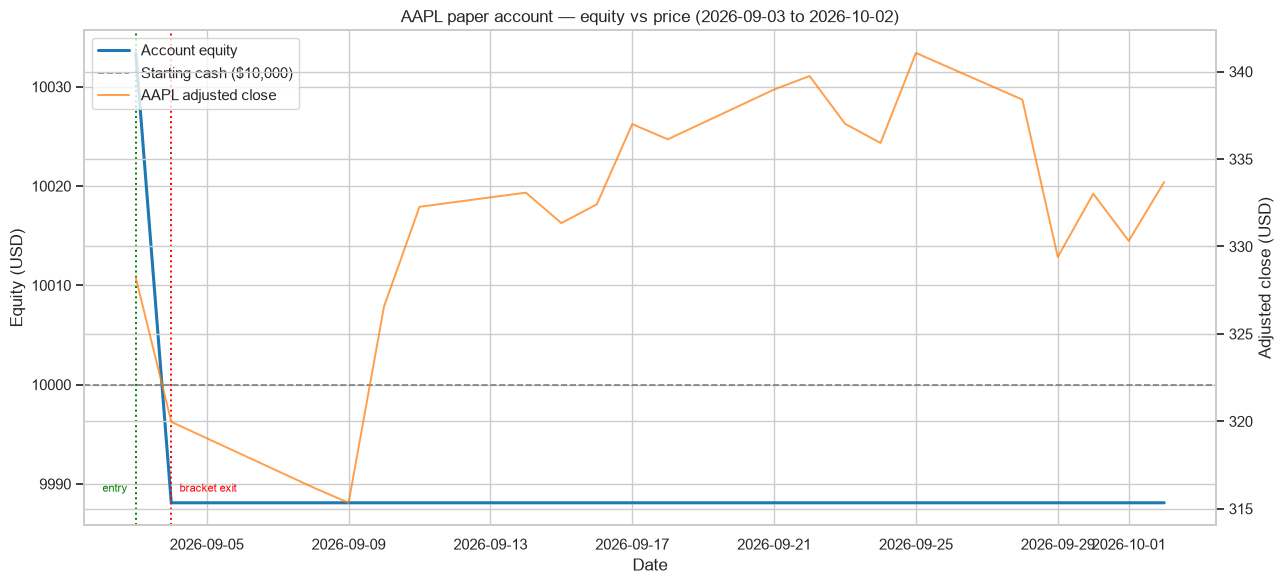

final equity: 9,988.10   total return: -0.12%


In [7]:
times = [ts for ts, _ in broker.equity_curve]
equity = [e for _, e in broker.equity_curve]
px_times = [b.timestamp for b in walk]
px_close = [b.close for b in walk]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(times, equity, color="tab:blue", linewidth=2.2, label="Account equity")
ax.axhline(broker.initial_cash, color="grey", linestyle="--", linewidth=1.2,
           label=f"Starting cash (${broker.initial_cash:,.0f})")
ax.set_xlabel("Date")
ax.set_ylabel("Equity (USD)")

ax2 = ax.twinx()
ax2.plot(px_times, px_close, color="tab:orange", linewidth=1.4, alpha=0.75,
         label=f"{ticker} adjusted close")
ax2.set_ylabel("Adjusted close (USD)")

for t in broker.trades:
    ax.axvline(t.entry_time, color="green", linestyle=":", linewidth=1.4)
    ax.axvline(t.exit_time, color="red", linestyle=":", linewidth=1.4)
    ax.annotate("entry", (t.entry_time, min(equity)), textcoords="offset points",
                xytext=(-6, 8), fontsize=8, color="green", ha="right")
    ax.annotate("bracket exit", (t.exit_time, min(equity)), textcoords="offset points",
                xytext=(6, 8), fontsize=8, color="red", ha="left")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")

ax.set_title(f"{ticker} paper account — equity vs price "
             f"({walk[0].timestamp.date()} to {walk[-1].timestamp.date()})")
plt.tight_layout()
plt.show()

print(f"final equity: {broker.equity:,.2f}   "
      f"total return: {broker.equity / broker.initial_cash - 1:+.2%}")

## Reading the chart

Blue is our account equity; orange is the adjusted close on the right axis. Equity steps **down
once**, at the stop-out, then sits **flat just below the starting line** for the rest of the
window — because the account is 100% in cash. Meanwhile the stock recovered and rose.

That is the honest lesson of a stop-loss: it **capped the loss**, but it also took us out of a move
that then went our way. A stop is insurance, and insurance has a premium. Paper trading lets you
feel that trade-off with no money on the line.

## Paper trading ≠ live trading

Everything in this notebook is frictionless. In the real market, none of it is:

- **No slippage** here — fills happen at the bar's own open/trigger prices. Live, size moves the price against you.
- **No latency** — your order lands at the exchange instantly. Live, the price has moved by the time it gets there.
- **No queue, no partial fills** — you always get the whole quantity. Live, a limit order may fill in pieces, or not at all.
- **No spread** — one price for buyers and sellers. Live, you cross the bid/ask on every market order.
- **Infinite liquidity** — any size fills. Live, thin names gap and stall.
- **Perfect discipline** — the code never panics, never moves a stop, never clicks twice. *You* might.

So a paper result is an **upper bound**. The gap between paper and live is mostly *you* — plus the
frictions above. Treat a great paper result as a hypothesis, not a promise.

> Educational analysis only — not financial advice. Past performance does not predict future returns.

## Recap

- Paper trading replays real prices with fake money, so you can rehearse the mechanics at zero risk.
- The loop is: look at the last bar → decide → place orders → wait for the next bar → see what filled.
- A market order fills at the next open; a limit order rests until price reaches it; a bracket adds an automatic take-profit and stop-loss.
- Bracket exits are checked after fills, the stop-loss wins ties, and a gap fills worse than the stop price.
- Every fill here is frictionless, so paper results are an upper bound on live results.

**Try this:** tighten the stop-loss (e.g. `stop_loss=round(last_close * 0.99, 2)`) and rerun — how
many trades close now, and how many of them are stop-outs? Then loosen it to `0.90` and compare.
Which setting kept you in the position, and which cut the loss sooner?